In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy as spy
import seaborn as sns
import sklearn as sk
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
from statsmodels.nonparametric.smoothers_lowess import lowess
from tqdm.auto import tqdm

In [6]:
# import local packages
from DPosIT import DPosIT
from exo_model import ExoModel
from new_em_model import EMNucModel, EMNucViewer
from nucleosomes import Nucleosome
from sklearn.metrics import r2_score

In [7]:
def make_position_matrix(batch, grouped_var=None, start=None, stop=None):
    starts, stops = batch[:, 0], batch[:, 1]
    return _make_position_matrix(starts, stops, grouped_var, start, stop)


def _make_position_matrix(starts, stops, grouped_var=None, start=None, stop=None):
    grouped_var = np.ones_like(starts) if grouped_var is None else grouped_var
    min_start = start if start else starts.min()
    stop = stop if stop else stops.max()
    imshow = np.zeros((starts.size, stop - min_start))
    for i, (cur_start, cur_stop) in enumerate(zip(starts, stops)):
        imshow[i, cur_start - min_start : cur_stop - min_start] = grouped_var[i]
    return imshow


def count_statistics(batch, model):
    prob_matrix = model.model.gij
    window_data = pd.DataFrame(batch, columns=["start", "stop"])
    window_data["mid"] = (window_data.start + window_data.stop) / 2
    nuc_indxex = np.argmax(prob_matrix, axis=1)
    window_data["dyad"] = model.positions_[nuc_indxex]
    window_data["dyadLH"] = np.max(prob_matrix, axis=1)
    window_data["tempLH"] = model.model.X.sum(axis=1)
    window_data["dyad_prob"] = model.weights_[nuc_indxex]
    statistics = make_stat_df(window_data)
    return window_data, statistics


def make_stat_df(window_data):
    group_size = window_data.groupby("dyad").size().reset_index()
    group_size.name = "size"
    group_size.rename(columns={0: "size"}, inplace=True)
    window_data["stat"] = window_data.dyad - window_data.mid
    window_data["stat"] = window_data.groupby("dyad", group_keys=False).stat.apply(
        lambda x: x / x.std()
    )
    window_data["stat"] = window_data["stat"] ** 2
    norm1 = window_data.groupby("dyad").stat.agg(sum)
    norm1.name = "stat"
    statistics = pd.merge(norm1, group_size, on="dyad").reset_index(drop=True)
    p_values = [
        1 - spy.stats.chi2.cdf(row.stat, row["size"])
        for i, row in statistics.iterrows()
    ]
    statistics["p_vals"] = p_values
    return statistics


def make_coverage(batch, start, stop):
    x = np.zeros(stop - start + 400)
    broad_start = start - 200
    lefts, rights = batch[:, 0].astype(int), batch[:, 1].astype(int)
    for left, right in zip(lefts, rights):
        x[left - broad_start : right - broad_start + 1] += 1
    return x[200:-200]


def plot_model_occ(dyads, nuc_template, start, end, dyad_weights=None):
    dyad_weights = np.ones_like(dyads) if dyad_weights is None else dyad_weights
    broad_start, broad_end = start - nuc_template.size, end + nuc_template.size
    # print(broad_start, broad_end)
    x = np.arange(broad_start, broad_end)
    y = np.zeros_like(x, dtype=float)
    for i, dyad in enumerate(dyads):
        start_pos = dyad - nuc_template.size // 2 - broad_start
        end_pos = dyad - broad_start + nuc_template.size // 2
        y[start_pos:end_pos] += nuc_template * dyad_weights[i]
    return (
        x[nuc_template.size : -nuc_template.size],
        y[nuc_template.size : -nuc_template.size],
    )


def adjusted_r2(exp_coverage, model_coverage, n_nucs, n_samples):
    rests_variation = (exp_coverage - model_coverage).var()
    model_variation = model_coverage.var()
    r2 = (rests_variation / (n_samples - n_nucs)) / (model_variation / (n_samples - 1))
    return r2

In [8]:
def __adjusted_r2_scorer(estimator, X, start, stop, nuc_template):
    n_params = 2 * estimator.n_nucs
    batch_size = estimator.X_.shape[0]
    r2 = r2_scorer(estimator, X)
    adjusted_r2 = 1 - (1 - r2) * (n_params - 1) / (n_params - batch_size - 1)
    return adjusted_r2


def log_LH_scorer(estimator, X):
    return estimator.score(X)


adjusted_r2_scorer = lambda estimator, X: __adjusted_r2_scorer(
    estimator, X, start, stop, nuc_template
)


def __reduced_chi2_scorer(estimator, X, start, stop, nuc_template, std_template):
    v = X.shape[0] - 2 * estimator.n_nucs
    viewer = EMNucViewer(estimator, start, stop)
    exp_coverage = viewer.make_coverage()[1]
    model_coverage = viewer.model_occ(nuc_template)[1]
    nuc_var = viewer.model_std(std_template)[1] ** 2
    plt.plot(nuc_var)
    dif2 = (exp_coverage - model_coverage) ** 2
    # stat = np.nansum(dif2 / nuc_var)
    return np.log(np.sum(dif2))


reduced_chi2_scorer = lambda estimator, X: __reduced_chi2_scorer(
    estimator, X, start, stop, nuc_template, std_template
)


def AIC_scorer(estimator, X):
    log_lh = estimator.score(X)
    aic = 4 * estimator.n_nucs - 2 * log_lh
    return aic


def BIC_scorer(estimator, X):
    n_params = 2 * estimator.n_nucs
    batch_size = X.shape[0]
    log_lh = estimator.score(X)
    bic = n_params * np.log(batch_size) - 2 * log_lh
    return bic


def __r2_scorer(estimator, X, start, stop, nuc_template):
    viewer = EMNucViewer(estimator, start, stop)
    exp_coverage = viewer.make_coverage()[1]
    model_coverage = viewer.model_occ(nuc_template)[1]
    r2 = r2_score(exp_coverage, model_coverage)
    return r2


r2_scorer = lambda estimator, X: __r2_scorer(estimator, X, start, stop, nuc_template)


scoring = {
    "adjusted_r2": adjusted_r2_scorer,
    "logLH": log_LH_scorer,
    "reduced_chi2": reduced_chi2_scorer,
    "aic": AIC_scorer,
    "bic": BIC_scorer,
    "r2": r2_scorer,
}

In [9]:
# MNASE1 = "data/reads/MNase_1/mapping/mnase_99_147_nodup.sam"
exo_sam = "/home/d_ryabov/MiSeq/scripts/data/reads/MNase-Exo_less2/SRR1802184_99_147_nodup.sam"

In [10]:
dpst = DPosIT(exo_sam, "sam", "tmp", reg_koef=0.18, max_iter=1000)
dpst.fit_exo("model_data/exo_probs.csv")
# plt.plot(dpst.fit_res)

/home/d_ryabov/MiSeq/NucDPosIT/src/NucDPosIT/Alignment_file_manager.py:72: UserWarning: found BAM file
  warnings.warn("found BAM file")
/home/d_ryabov/MiSeq/NucDPosIT/src/NucDPosIT/Alignment_file_manager.py:81: UserWarning: index found
  warnings.warn("index found")


ExoModel(max_iter=1000)

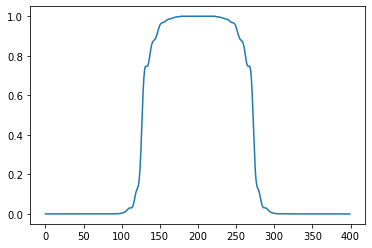

In [11]:
N = 1000000
kde = KernelDensity()

digested_nucs = dpst.digest_nucs(N)
pos = np.array(list(map(lambda x: [x.start, x.end], digested_nucs)))
nuc_template = make_position_matrix(pos, start=-200, stop=200).sum(axis=0) / N
plt.plot(nuc_template)

In [12]:
def nuc_occupancy_prob(nuc_pos, dyad, template):
    rel_nucpos = nuc_pos - dyad + template.size // 2
    if rel_nucpos >= 0 and rel_nucpos < len(template):
        return template[rel_nucpos]
    else:
        return 0

In [13]:
def plot_model_occ(dyads, nuc_template, start, end, dyad_weights=None):
    dyad_weights = np.ones_like(dyads) if dyad_weights is None else dyad_weights
    broad_start, broad_end = start - nuc_template.size, end + nuc_template.size
    # print(broad_start, broad_end)
    x = np.arange(broad_start, broad_end)
    y = np.zeros_like(x, dtype=float)
    for i, dyad in enumerate(dyads):
        start_pos = dyad - nuc_template.size // 2 - broad_start
        end_pos = dyad - broad_start + nuc_template.size // 2
        y[start_pos:end_pos] += nuc_template * dyad_weights[i]
    return (
        x[nuc_template.size : -nuc_template.size],
        y[nuc_template.size : -nuc_template.size],
    )

In [14]:
def plot_occupancy(dyad_positions, weights, start, end, template):
    x = np.arange(start, end)
    y = np.zeros_like(x, dtype=float)
    for nuc_pos in range(start, end):
        for dyad_pos, dyad_weight in zip(dyad_positions, weights):
            y[nuc_pos - start] += (
                nuc_occupancy_prob(nuc_pos, dyad_pos, template) * dyad_weight
            )
    return x, y

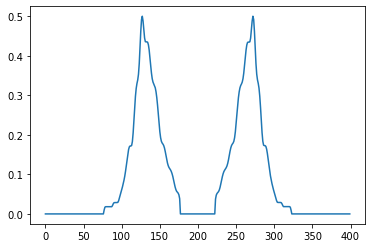

In [15]:
std_template = make_position_matrix(pos, start=-200, stop=200).std(0)
plt.plot(std_template)

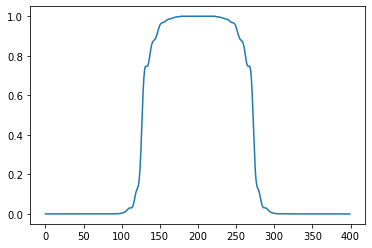

In [20]:
# mean_df.iloc[9].T.plot()
plt.plot(nuc_template)

In [22]:
chromosomes = dpst.file_manager.chromosomes
chromosomes

('NC_001133.9',
 'NC_001134.8',
 'NC_001135.5',
 'NC_001136.10',
 'NC_001137.3',
 'NC_001138.5',
 'NC_001139.9',
 'NC_001140.6',
 'NC_001141.2',
 'NC_001142.9',
 'NC_001143.9',
 'NC_001144.5',
 'NC_001145.3',
 'NC_001146.8',
 'NC_001147.6',
 'NC_001148.4',
 'NC_001224.1')

  0%|          | 0/2000 [00:00<?, ?it/s]

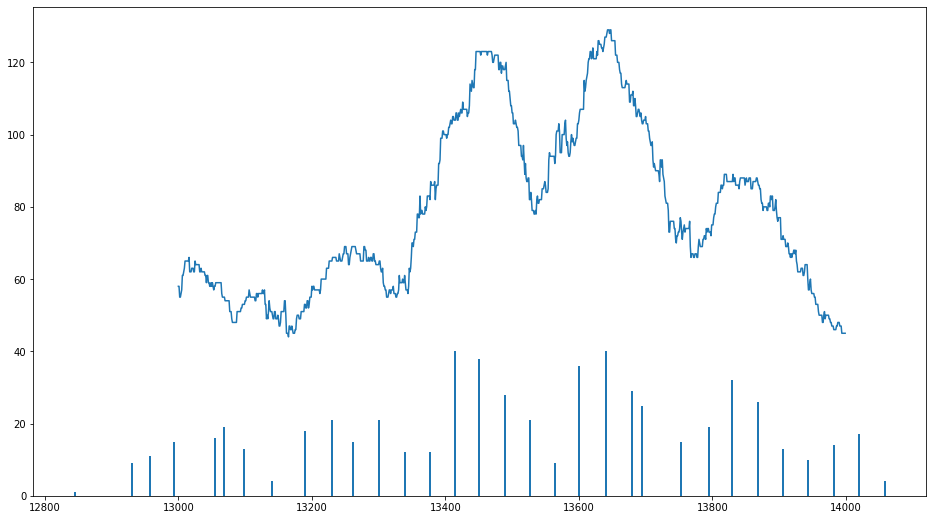

In [66]:
n_nucs = 35
winlen = 1000
start = 13000
stop = 14000
chromosome = "NC_001133.9"

model = EMNucModel(
    n_nucs, "EM", dpst.fit_res, max_iter=2000, drop_treshold=0.001, tol=1e-8, temp=0.1
)

plt.figure(figsize=(16, 9))
stat_df = pd.DataFrame()
window_df = pd.DataFrame()

for i, batch in enumerate(
    dpst.iterover(chromosome, win_len=winlen, start=start, stop=stop, step=100)
):
    batch, qids = batch[:, :2].astype(int), batch[:, 2]
    model.fit(batch)
    w_opt, theta_opt = model.weights_, model.positions_
    cluster_occ = model.cluster_occupancy()
    plt.bar(theta_opt, cluster_occ, 3)

    window_data, cur_stat = count_statistics(batch, model)
    window_data["fold"] = i
    window_data["qid"] = qids

    # plt.figure(figsize=(16, 9))
    # sns.histplot(model.model.X.sum(axis=1), kde=True, bins=50)
    # plt.show()right_cords

    stat_df = pd.concat([stat_df, cur_stat])
    window_df = pd.concat([window_df, window_data])

    # _ = plt.hist(model.model.X.sum(axis=1), bins=100)
    # plt.show()

stat_df.reset_index(drop=True, inplace=True)
window_df.reset_index(drop=True, inplace=True)
coverage = make_coverage(window_df[["start", "stop"]].to_numpy(), start, stop)
plt.plot(np.arange(start, stop), coverage)

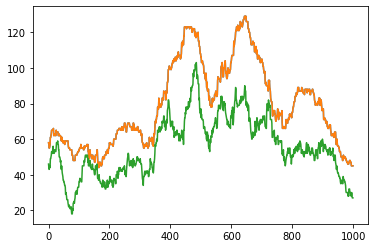

In [67]:
plt.plot(make_coverage(window_data[["start", "stop"]].to_numpy(), start, stop))
plt.plot(
    make_coverage(
        window_data.drop_duplicates("qid")[["start", "stop"]].to_numpy(), start, stop
    )
)
plt.plot(
    np.array(
        dpst.alignemnt.count_coverage(
            chromosome, start, stop, read_callback="nofilter", quality_threshold=0
        )
    ).sum(0)
)

In [68]:
def plot_model_occ(dyads, nuc_template, start, end, dyad_weights=None):
    dyad_weights = np.ones_like(dyads) if dyad_weights is None else dyad_weights
    broad_start, broad_end = start - 2 * nuc_template.size, end + 2 * nuc_template.size
    # print(broad_start, broad_end)
    x = np.arange(broad_start, broad_end)
    y = np.zeros_like(x, dtype=float)
    for i, dyad in enumerate(dyads):
        start_pos = dyad - nuc_template.size // 2 - broad_start
        end_pos = dyad - broad_start + nuc_template.size // 2
        y[start_pos:end_pos] += nuc_template * dyad_weights[i]
    return (
        x[2 * nuc_template.size : -2 * nuc_template.size],
        y[2 * nuc_template.size : -2 * nuc_template.size],
    )

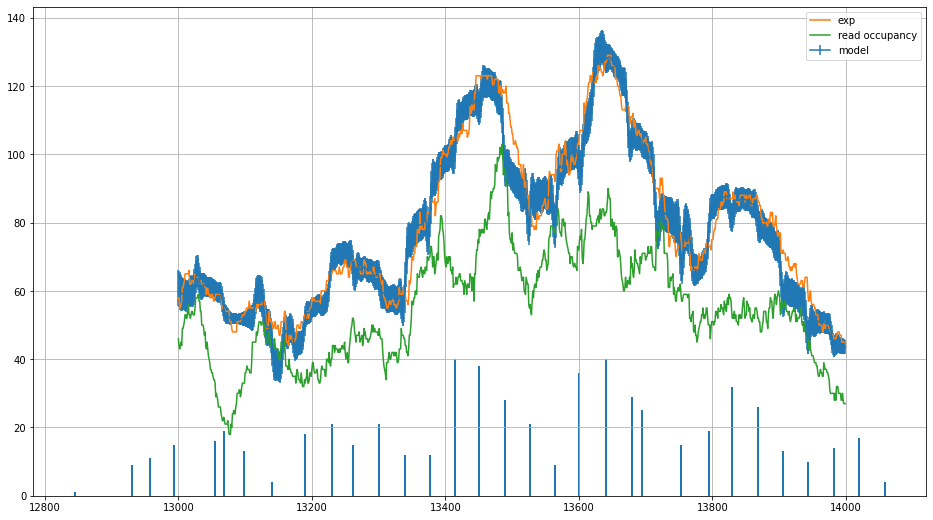

In [69]:
dyad_x, dyad_y = plot_model_occ(window_df.dyad.to_numpy(), nuc_template, start, stop)

# weights = window_df.dyad.apply(lambda x: stat_df.loc[stat_df.dyad == x, 'size'].values[0]).to_numpy()
sem_x, sem_y = plot_model_occ(
    stat_df.dyad.to_numpy(),
    std_template,
    start,
    stop,
    np.sqrt(stat_df["size"].to_numpy()),
)

plt.figure(figsize=(16, 9))
plt.errorbar(dyad_x, dyad_y, sem_y, label="model")
plt.plot(np.arange(start, stop), coverage, label="exp")
plt.bar(theta_opt, cluster_occ, 3)


plt.plot(
    np.arange(start, stop),
    np.array(
        dpst.alignemnt.count_coverage(
            chromosome, start, stop, read_callback="nofilter", quality_threshold=0
        )
    ).sum(0),
    label="read occupancy",
)


plt.legend()
plt.grid()

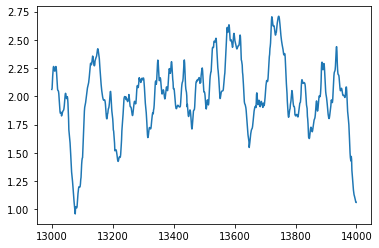

In [157]:
plt.plot(sem_x, np.sqrt(sem_y))

In [158]:
rmsd = np.sqrt(np.sum(((coverage - dyad_y) / len(batch)) ** 2))
rmsd

0.31726652738952194

<AxesSubplot:ylabel='Density'>

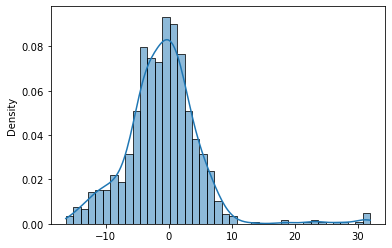

In [159]:
v = dyad_y - coverage
# v = (v - v.mean()) / v.std()

sns.histplot(v, kde=True, stat="density")

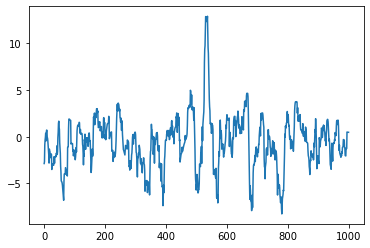

In [160]:
plt.plot(v / np.sqrt(sem_y))

<AxesSubplot:ylabel='Count'>

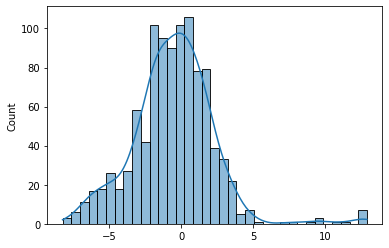

In [161]:
sns.histplot(v / np.sqrt(sem_y), kde=True)

In [163]:
test_grid = {
    "n_nucs": np.arange(10, 90, 2),
    "cluster_strategy": ["SEM"],
    "max_iter": [1000],
    "tol": [0.01],
    "temp": [0.1],
}


def __custom_cv(X, n=5):
    for i in range(n):
        yield np.arange(X.shape[0]), np.arange(X.shape[0])


custom_cv = lambda: __custom_cv(batch)


gs = GridSearchCV(
    EMNucModel(1, "SEM", dpst.fit_res, 1000),
    test_grid,
    n_jobs=16,
    verbose=3,
    scoring=scoring,
    refit=False,
    error_score="raise",
    cv=custom_cv(),
)

# add reduce chi square

grid_res = gs.fit(batch)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [150]:
grid_df = pd.DataFrame(grid_res.cv_results_)

In [151]:
grid_df.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cluster_strategy,param_max_iter,param_n_nucs,param_temp,param_tol,params,...,std_test_bic,rank_test_bic,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2
0,6.773994,0.201308,0.270915,0.004927,SEM,1000,10,0.1,0.01,"{'cluster_strategy': 'SEM', 'max_iter': 1000, ...",...,1.121314,1,-1.247297,-1.247297,-1.247297,-1.247297,-1.247297,-1.247297,0.000000e+00,40
1,6.964831,0.099889,0.290525,0.003769,SEM,1000,12,0.1,0.01,"{'cluster_strategy': 'SEM', 'max_iter': 1000, ...",...,0.975715,2,-0.420736,-0.420736,-0.420736,-0.420736,-0.420736,-0.420736,5.551115e-17,39
2,8.474979,0.744531,0.312918,0.013976,SEM,1000,14,0.1,0.01,"{'cluster_strategy': 'SEM', 'max_iter': 1000, ...",...,1.020729,3,0.014754,0.014754,0.014754,0.014754,0.014754,0.014754,0.000000e+00,38
3,48.017486,1.979961,0.315500,0.018420,SEM,1000,16,0.1,0.01,"{'cluster_strategy': 'SEM', 'max_iter': 1000, ...",...,2.103504,4,0.481297,0.482469,0.482224,0.482469,0.481297,0.481951,5.413253e-04,37
4,50.654682,0.658426,0.329921,0.001310,SEM,1000,18,0.1,0.01,"{'cluster_strategy': 'SEM', 'max_iter': 1000, ...",...,0.925796,5,0.732282,0.732282,0.732282,0.732282,0.732282,0.732282,0.000000e+00,36


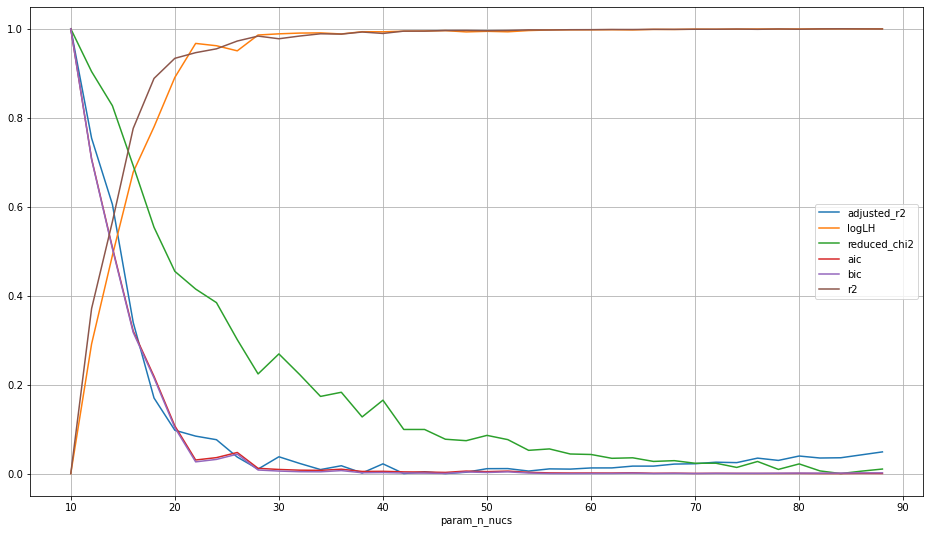

In [152]:
mm_scaler = sk.preprocessing.MinMaxScaler()

plt.figure(figsize=(16, 9))
for loss in scoring.keys():
    y = grid_df[f"mean_test_{loss}"]
    # print(y.to_numpy())
    scaled_y = mm_scaler.fit_transform(y.to_numpy().reshape(-1, 1)).flatten()
    loss_std = mm_scaler.fit_transform(
        grid_df[f"std_test_{loss}"].to_numpy().reshape(-1, 1)
    ).flatten()
    sns.lineplot(data=grid_df, x="param_n_nucs", y=scaled_y, label=loss)
    # plt.errorbar(x=test_grid['n_nucs'], y=scaled_y, yerr=loss_std)


plt.grid()

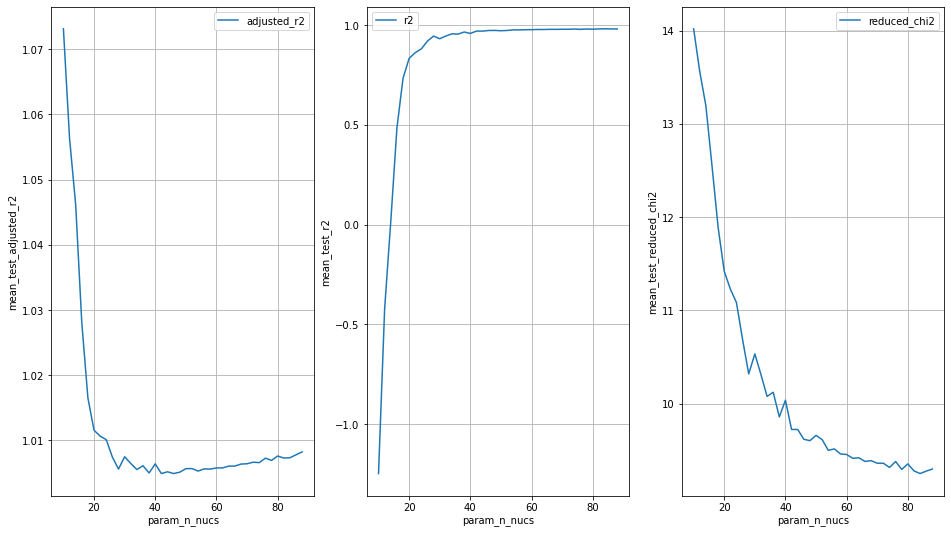

In [173]:
def plot_metrics(grid_df):
    gig, (ax1, ax2, ax3) = plt.subplots(
        1, 3, sharex=True, sharey=False, figsize=(16, 9)
    )
    sns.lineplot(
        data=grid_df,
        x="param_n_nucs",
        y="mean_test_adjusted_r2",
        ax=ax1,
        label="adjusted_r2",
    )
    sns.lineplot(data=grid_df, x="param_n_nucs", y="mean_test_r2", ax=ax2, label="r2")
    sns.lineplot(
        data=grid_df,
        x="param_n_nucs",
        y="mean_test_reduced_chi2",
        ax=ax3,
        label="reduced_chi2",
    )
    ax1.grid()
    ax2.grid()
    ax3.grid()


plot_metrics(grid_df)

In [119]:
c = lambda x, b: x / (x + b)

popt, pcov = spy.optimize.curve_fit(
    c, grid_df.mean_test_r2.to_numpy(), grid_df.param_n_nucs.to_numpy()
)

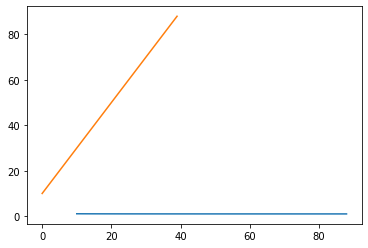

In [120]:
b = popt
x = grid_df.param_n_nucs
plt.plot(x, c(x, b))

plt.plot(x)

In [121]:
b

array([-0.7109464])

In [126]:
test_grid = {
    "n_nucs": np.arange(10, 90, 2),
    "cluster_strategy": ["SEM", "EM"],
    "max_iter": [500, 1000, 3000],
}


gs = GridSearchCV(
    EMNucModel(1, "SEM", dpst.fit_res, 1000),
    test_grid,
    n_jobs=16,
    verbose=3,
    scoring=scoring,
    refit=False,
    error_score="raise",
    cv=custom_cv(),
)

gs_niter = gs.fit(batch)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py:63: UserWarning: Failed to kill subprocesses on this platform. Please installpsutil: https://github.com/giampaolo/psutil
Details:
Traceback (most recent call last):
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 59, in _kill_process_tree_without_psutil
    _posix_recursive_kill(process.pid)
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 111, in _posix_recursive_kill
    ["pgrep", "-P", str(pid)], stderr=None, text=True
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 356, in check_output
    **kwargs).stdout
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 423, in run
    with Popen(*popenargs, **kwargs) as process:
TypeError: __init__() got an unexpected keyword argument 'text'

 

KeyboardInterrupt: 

In [122]:
niter_dff = pd.DataFrame(gs_niter.cv_results_)

In [123]:
niter_dff.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cluster_strategy,param_max_iter,param_n_nucs,params,split0_test_adjusted_r2,split1_test_adjusted_r2,...,std_test_bic,rank_test_bic,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2
0,2.370593,0.254583,0.227990,0.008257,SEM,500,10,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.054905,1.024227,...,6018.915015,4,-0.337955,0.409622,-0.654710,0.057172,0.694903,0.033806,0.488076,236
1,2.407368,0.262400,0.247035,0.012781,SEM,500,12,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.023278,1.021277,...,3185.301342,10,0.535449,0.575392,0.259356,0.400527,0.693719,0.492889,0.149679,230
2,2.374619,0.285484,0.241349,0.020781,SEM,500,14,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.005423,1.020046,...,4118.568125,13,0.908611,0.662184,0.303117,0.537841,0.881611,0.658673,0.225035,223
3,2.166261,0.222463,0.237026,0.038447,SEM,500,16,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.004689,1.012217,...,3431.141727,25,0.931779,0.822259,0.673321,0.717017,0.930583,0.814992,0.106511,218
4,2.128344,0.239011,0.234028,0.004887,SEM,500,18,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.004473,1.006954,...,2593.894639,23,0.942868,0.911188,0.824009,0.891093,0.961669,0.906165,0.047811,208


In [124]:
niter_dff.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cluster_strategy,param_max_iter,param_n_nucs,params,split0_test_adjusted_r2,split1_test_adjusted_r2,...,std_test_bic,rank_test_bic,split0_test_r2,split1_test_r2,split2_test_r2,split3_test_r2,split4_test_r2,mean_test_r2,std_test_r2,rank_test_r2
0,2.370593,0.254583,0.227990,0.008257,SEM,500,10,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.054905,1.024227,...,6018.915015,4,-0.337955,0.409622,-0.654710,0.057172,0.694903,0.033806,0.488076,236
1,2.407368,0.262400,0.247035,0.012781,SEM,500,12,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.023278,1.021277,...,3185.301342,10,0.535449,0.575392,0.259356,0.400527,0.693719,0.492889,0.149679,230
2,2.374619,0.285484,0.241349,0.020781,SEM,500,14,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.005423,1.020046,...,4118.568125,13,0.908611,0.662184,0.303117,0.537841,0.881611,0.658673,0.225035,223
3,2.166261,0.222463,0.237026,0.038447,SEM,500,16,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.004689,1.012217,...,3431.141727,25,0.931779,0.822259,0.673321,0.717017,0.930583,0.814992,0.106511,218
4,2.128344,0.239011,0.234028,0.004887,SEM,500,18,"{'cluster_strategy': 'SEM', 'max_iter': 500, '...",1.004473,1.006954,...,2593.894639,23,0.942868,0.911188,0.824009,0.891093,0.961669,0.906165,0.047811,208


In [23]:
def __custom_cv(X, n=5):
    for i in range(n):
        yield np.arange(X.shape[0]), np.arange(X.shape[0])

Fitting 1 folds for each of 23 candidates, totalling 23 fits
{'cluster_strategy': 'EM', 'max_iter': 3000, 'n_nucs': 33, 'temp': 0.1, 'tol': 1e-07}


  0%|          | 0/3000 [00:00<?, ?it/s]

Fitting 1 folds for each of 23 candidates, totalling 23 fits
{'cluster_strategy': 'EM', 'max_iter': 3000, 'n_nucs': 23, 'temp': 0.1, 'tol': 1e-07}


  0%|          | 0/3000 [00:00<?, ?it/s]

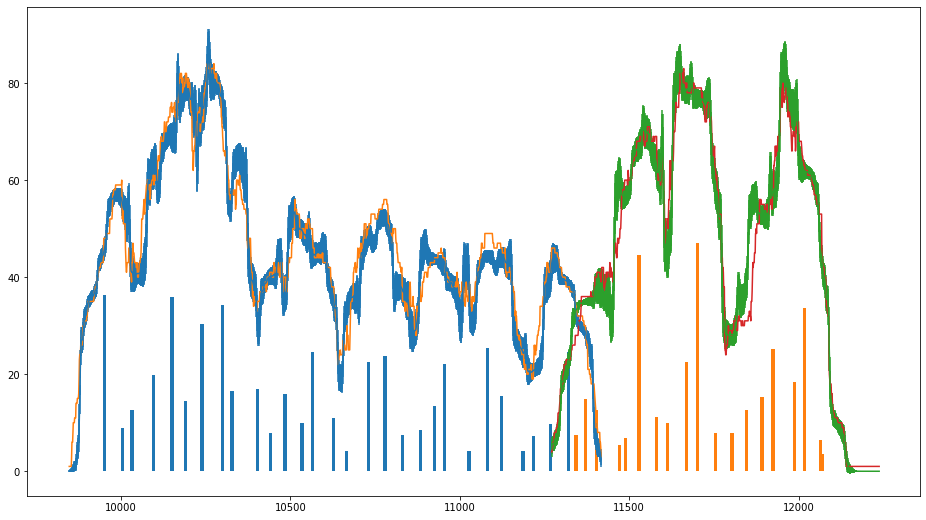

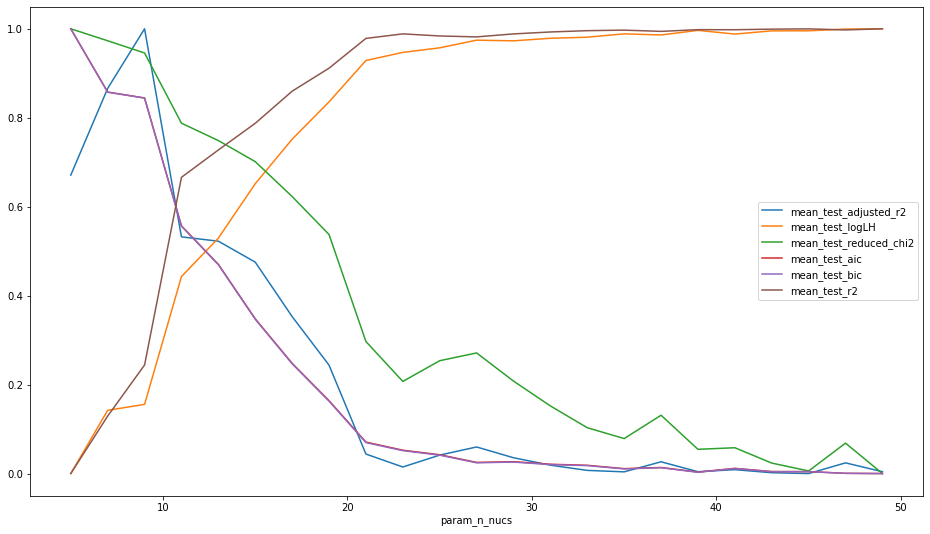

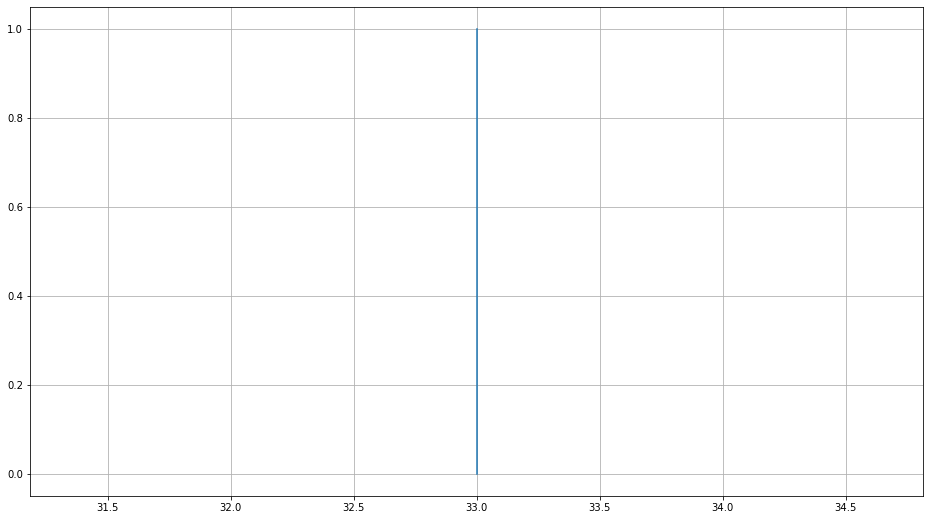

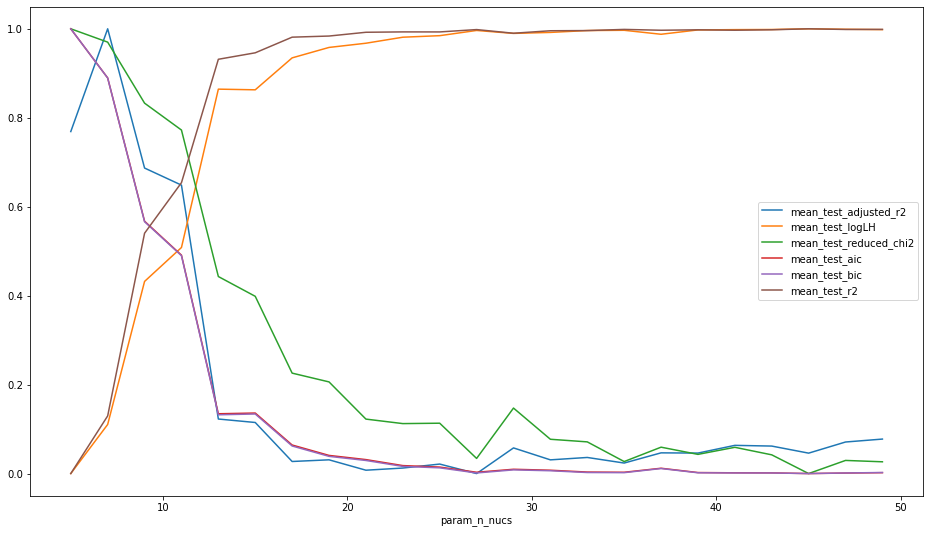

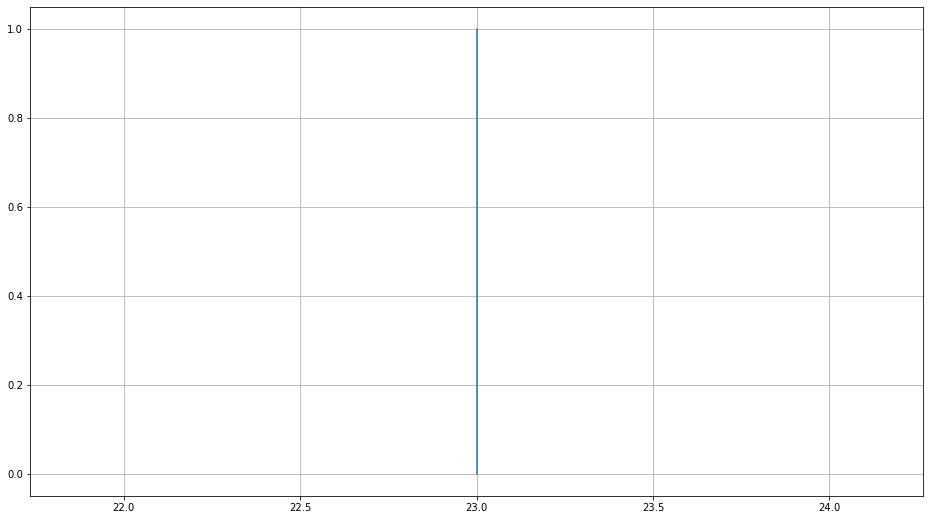

In [132]:
n_nucs = 30
winlen = 500
start = 10000
stop = 12000
chromosome = "NC_001133.9"
mm_scaler = sk.preprocessing.MinMaxScaler()
df_res = pd.DataFrame()

fit_results = {}
best_models = []


test_grid = {
    "n_nucs": np.arange(5, 50, 2),
    "cluster_strategy": ["EM"],
    "max_iter": [3000],
    "tol": [1e-7],
    "temp": [0.1],
}


scoring = {
    "adjusted_r2": adjusted_r2_scorer,
    "logLH": log_LH_scorer,
    "reduced_chi2": reduced_chi2_scorer,
    "aic": AIC_scorer,
    "bic": BIC_scorer,
    "r2": r2_scorer,
}


fit_results["meta"] = {"test_grid": test_grid, "scoring": scoring}
fit_results["fit_data"] = {}

fig, ax = plt.subplots(figsize=(16, 9))


for i, batch in enumerate(
    dpst.iterover(chromosome, win_len=winlen, start=start, stop=stop, step=250)
):
    batch, qids = batch[:, :2].astype(int), batch[:, 2]
    win_start, win_stop = batch[:, 0].min(), batch[:, 1].max()
    custom_cv = lambda: __custom_cv(batch, 1)
    gs = GridSearchCV(
        EMNucModel(1, "SEM", dpst.fit_res, 1000),
        test_grid,
        n_jobs=16,
        verbose=3,
        scoring=scoring,
        refit=False,
        error_score="raise",
        cv=custom_cv(),
    )
    gs_res = gs.fit(batch)
    gs_df = pd.DataFrame(gs_res.cv_results_)
    gs_df["nbatch"] = i
    df_res = pd.concat([df_res, gs_df])

    metrics_columns = gs_df.columns[df_res.columns.str.startswith("mean_test")]
    metric_values = mm_scaler.fit_transform(gs_df[metrics_columns])
    gs_df[metrics_columns] = metric_values
    metrics = gs_df[["param_n_nucs", *metrics_columns]]
    y = metrics.mean_test_logLH
    x = metrics.param_n_nucs
    best_nucs = round(x[(abs(y - 1) < 0.02).argmax()])

    metrics_columns = gs_df.columns[gs_df.columns.str.startswith("mean_test")]
    metric_values = mm_scaler.fit_transform(gs_df[metrics_columns])
    gs_df[metrics_columns] = metric_values
    metrics = gs_df[["param_n_nucs", "nbatch", *metrics_columns]]
    metrics.drop(columns=["nbatch"]).plot(x="param_n_nucs", figsize=(16, 9))
    fig2, ax2 = plt.subplots(figsize=(16, 9))
    ax2.grid()
    ax2.plot([best_nucs, best_nucs], [0, 1])
    fig2.show()

    best_params = gs_df.query("param_n_nucs == @best_nucs").reset_index().params[0]
    print(best_params)
    best_model = EMNucModel(**best_params, fit_res=dpst.fit_res)
    best_model.fit(batch)

    best_models.append(best_model)
    EMNucViewer(best_model, win_start, win_stop).plot(nuc_template, std_template, ax=ax)

    fit_results["fit_data"][i] = {
        "pos": best_model.positions_,
        "weights": best_model.weights_,
        "heights": best_model.cluster_occupancy(),
        "gij": best_model.model.gij,
        "X": best_model.model.X,
    }

In [140]:
v = EMNucViewer(best_model, win_start, win_stop)
v.window_df

,start,stop,mid,dyad,dyadLH,tempLH,dyad_prob
0,11271,11387,11329.0,11343,1.000000,0.000005,0.023415
1,11271,11425,11348.0,11343,0.990189,0.000045,0.023415
2,11271,11424,11347.5,11343,0.985520,0.000036,0.023415
3,11271,11413,11342.0,11343,0.998697,0.000099,0.023415
4,11273,11424,11348.5,11343,0.956710,0.000017,0.023415
...,...,...,...,...,...,...,...
312,11993,12138,12065.5,12064,0.935206,0.000161,0.020544
313,11993,12140,12066.5,12064,0.648612,0.000123,0.020544
314,11993,12141,12067.0,12069,0.566502,0.000101,0.011128
315,11996,12141,12068.5,12069,0.994956,0.000115,0.011128


In [ ]:
window_df

In [129]:
fit_results['fit_data']

{0: {'pos': array([ 9847,  9847,  9952, 10004, 10048, 10097, 10150, 10200, 10246,
         10295, 10328, 10402, 10442, 10495, 10554,  9847,  9847]),
  'weights': array([0.        , 0.        , 0.13295149, 0.04734724, 0.03866177,
         0.07146316, 0.13093674, 0.08195581, 0.08883287, 0.0929751 ,
         0.08687591, 0.06209873, 0.03723541, 0.06108162, 0.0602312 ,
         0.        , 0.        ]),
  'heights': array([ 0.        ,  0.        , 36.16280593, 12.87844909, 10.51600241,
         19.43797906, 35.61479436, 22.29197905, 24.1625405 , 25.28922828,
         23.63024804, 16.89085499, 10.12803129, 16.61419975, 16.38288725,
          0.        ,  0.        ]),
  'gij': array([[0., 0., 1., ..., 0., 0., 0.],
         [0., 0., 1., ..., 0., 0., 0.],
         [0., 0., 1., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 1., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]),
  'X': array([[0.00000000e+00, 0.00000000e+00, 4.41941208e-06, ..

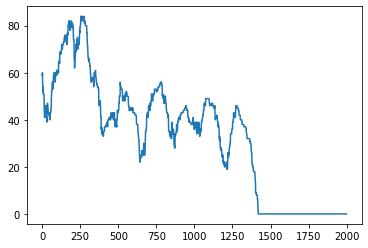

In [136]:
plt.plot(make_coverage(next(dpst.iterover(chromosome, win_len=winlen, start=start, stop=stop))[:, :2], start, stop))

In [125]:
winlen = 200

for c in range(start, stop, winlen):
    batch = next(dpst.iterover(chromosome, win_len=200, start=start, stop=stop))
    batch = batch[:, :2], batch[:, 2]

In [126]:
def crop_batch(batch, start, stop):
    # x = np.arange(start, stop + 1)
    min_left = batch[:, 0].min() if batch[:, 0].min() < start else start
    max_right = batch[:, 1].max() if batch[:, 1].max() > stop else stop
    x = np.arange(min_left, max_right + 1)
    y = np.zeros_like(x)
    

(array([['9858', '10002'],
        ['9878', '10002'],
        ['9876', '10002'],
        ['9854', '10002'],
        ['9855', '10002'],
        ['9855', '10003'],
        ['9847', '10003'],
        ['9854', '10003'],
        ['9877', '10006'],
        ['9875', '10006'],
        ['9858', '10006'],
        ['9957', '10106'],
        ['9921', '10012'],
        ['9859', '10012'],
        ['9881', '10012'],
        ['9877', '10012'],
        ['9871', '10012'],
        ['9867', '10013'],
        ['9859', '10013'],
        ['9877', '10013'],
        ['9867', '10014'],
        ['9876', '10014'],
        ['9855', '10014'],
        ['9867', '10015'],
        ['9967', '10122'],
        ['9967', '10149'],
        ['9967', '10112'],
        ['9974', '10119'],
        ['9975', '10129'],
        ['9975', '10068'],
        ['9975', '10085'],
        ['9976', '10126'],
        ['9876', '10026'],
        ['9877', '10026'],
        ['9902', '10026'],
        ['9887', '10026'],
        ['9899', '10026'],
 

In [43]:
win_start

14212

In [44]:
win_stop

15141

In [38]:
fit_results["fit_data"][0]

{'pos': array([ 9847,  9847,  9952, 10004, 10032, 10096, 10150, 10190, 10239,
        10300, 10328, 10402, 10442, 10484, 10534, 10566, 10628, 10666,
        10730, 10779, 10830, 10884, 10926, 10955, 11027, 11082, 11123,
        11186, 11218, 11268, 11321, 11344,  9847]),
 'weights': array([0.        , 0.        , 0.07248447, 0.01777527, 0.02522516,
        0.03972169, 0.07175861, 0.02895089, 0.0606299 , 0.06843747,
        0.03297083, 0.03385629, 0.01558246, 0.03186214, 0.0198024 ,
        0.0491874 , 0.02203555, 0.00814924, 0.04510052, 0.04742669,
        0.01504303, 0.01688495, 0.02686451, 0.0440964 , 0.00819897,
        0.05079285, 0.03111184, 0.00849797, 0.01441086, 0.01929253,
        0.04905628, 0.01079284, 0.        ]),
 'heights': array([ 0.        ,  0.        , 36.24223742,  8.88763526, 12.61257953,
        19.86084494, 35.8793061 , 14.47544289, 30.31494975, 34.21873523,
        16.48541361, 16.92814688,  7.79122784, 15.93107003,  9.90119796,
        24.59369977, 11.01777274,

<AxesSubplot:>

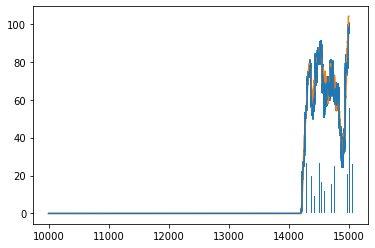

In [41]:
EMNucViewer(best_model, start, stop).plot(nuc_template, std_template)

In [276]:
fit_results['fit_data'][4]['pos']

array([14212, 14308, 14366, 14444, 14521, 14599, 14676, 14753, 14831,
       14908, 14986, 15032, 14212])

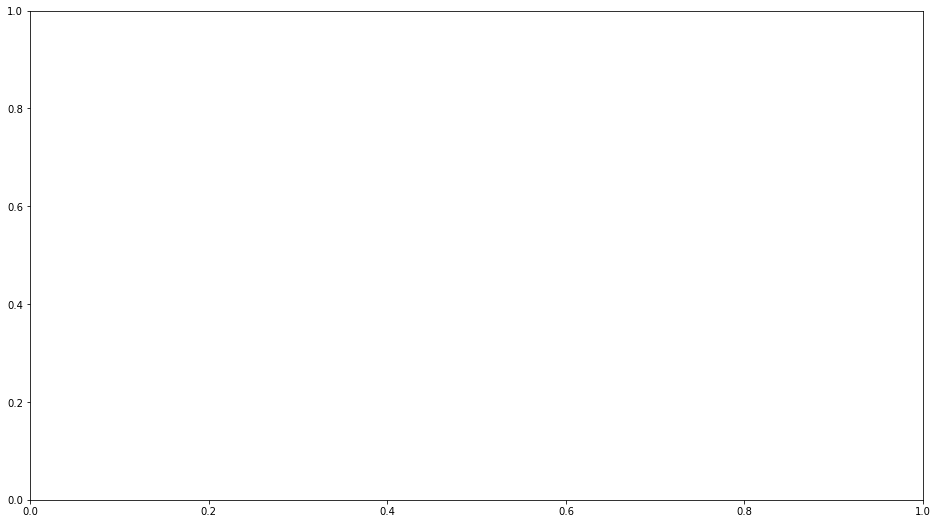

In [234]:
fig, ax = plt.subplots(figsize=(16, 9))


# fit_results["fit_data"][0]['X']

In [233]:
fit_results["fit_data"][4]['gij']

array([[0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.50606171, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.99882417, 0.        ,
        0.        ]])

In [229]:
batch.shape

(414, 2)

In [123]:
t = EMNucModel(10, "EM", dpst.fit_res)
t.fit(batch)
t.cluster_occupancy()

  0%|          | 0/1000 [00:00<?, ?it/s]

array([112,  47,  21,  50,  35,  32,  32,  11,  74,   0])

In [139]:
t.model.gij[0]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [144]:
t.model.gij.argmax(axis=1)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0,
       2, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3, 0, 0, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 3, 3, 3, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3,
       3, 3, 3, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 4, 0, 4, 4, 0, 4, 0, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 0, 0, 0, 4, 4, 4, 0, 4, 0, 4, 0, 0, 5, 0, 0, 5, 0, 0, 0, 0,
       0, 0, 0, 5, 5, 0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 0, 5, 5,
       5, 5, 5, 5, 0, 5, 5, 5, 5, 5, 5, 0, 5, 0, 0, 5, 5, 0, 6, 6, 6, 6,
       0, 0, 0, 6, 6, 0, 6, 6, 0, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 6, 0, 6, 7,

In [533]:
metrics

,param_n_nucs,nbatch,mean_test_adjusted_r2,mean_test_logLH,mean_test_reduced_chi2,mean_test_aic,mean_test_bic,mean_test_r2
0,5,4,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000
1,7,4,0.545340,0.366001,0.862462,0.633421,0.632261,0.623645
2,9,4,0.337859,0.573267,0.757296,0.425858,0.424104,0.821976
3,11,4,0.350501,0.645707,0.731118,0.353360,0.351492,0.852292
4,13,4,0.027217,0.913915,0.384745,0.084747,0.082068,0.988107
5,15,4,0.005667,0.972466,0.239978,0.026163,0.023419,0.996275
6,17,4,0.004498,0.980953,0.208960,0.017733,0.015102,0.997166
7,19,4,0.003590,0.985037,0.182509,0.013712,0.011210,0.997800
8,21,4,0.002154,0.979826,0.149739,0.019004,0.016664,0.998413
9,23,4,0.003002,0.987289,0.145444,0.011598,0.009376,0.998498


In [390]:
# metrics.drop(columns=['nbatch']).plot(x='param_n_nucs', figsize=(16, 9))

27


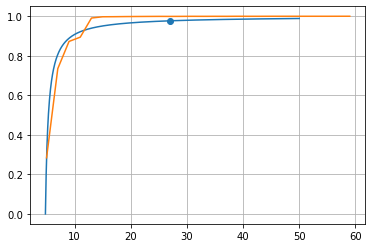

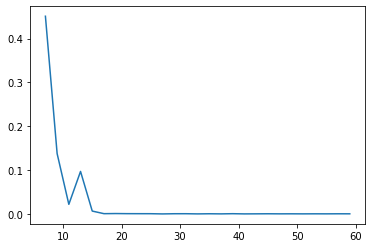

In [508]:
nbatch = 4

metrics_columns = df_res.columns[df_res.columns.str.startswith("mean_test")]
metric_values = mm_scaler.fit_transform(df_res[metrics_columns])
df_res[metrics_columns] = metric_values
metrics = df_res.query("nbatch == @nbatch")[["param_n_nucs", *metrics_columns]]

y = metrics.mean_test_r2
x = metrics.param_n_nucs

f = lambda x, b, c: (x - c) / (x - c + b)
popt, pcov = spy.optimize.curve_fit(f, x, y)

b, c = popt
ls = np.linspace(c, 50, 1000)
plt.plot(ls, f(ls, b, c))
plt.plot(x, y)
plt.grid()

nopt = x[(y.diff().abs() < 0.0002).argmax()]
print(nopt)
plt.scatter(nopt, f(nopt, b, c))


plt.figure()
plt.plot(x, y.diff())

25

In [318]:
b

array([0.74481189])

In [1766]:
sort_df = window_df.sort_values("mid")

<AxesSubplot:>

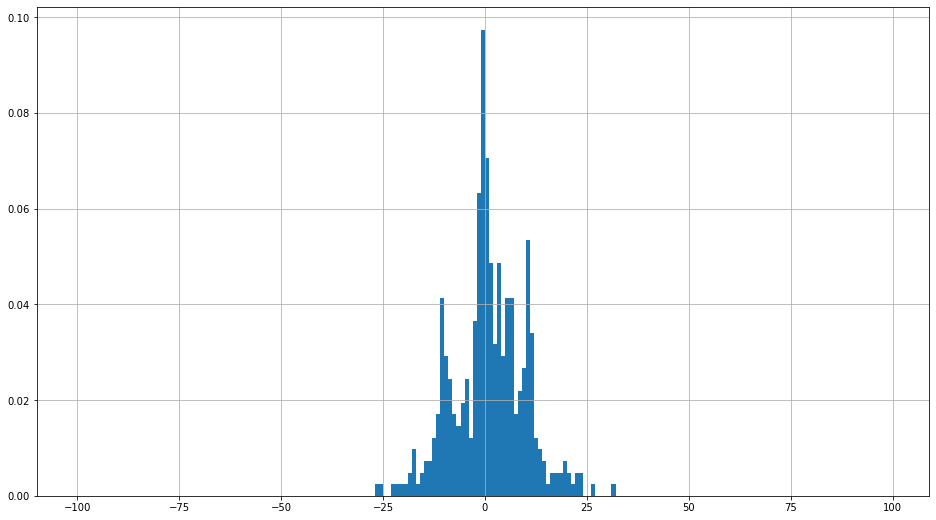

In [1767]:
plt.figure(figsize=(16, 9))
(sort_df.mid - sort_df.dyad).hist(bins=np.arange(-100, 100, 1), density=True)

<AxesSubplot:>

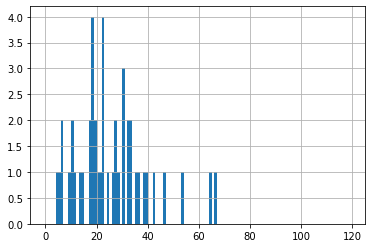

In [1768]:
stat_df.sort_values("dyad").dyad.diff().hist(bins=np.arange(0, 120, 1))

In [1769]:
# final_model = EMNucModel(stat_df.shape[0], 'DROPSEM', dpst.fit_res, max_iter=300)
# final_model.fit(window_df[['start', 'stop']].to_numpy(), (stat_df['size'] / stat_df['size'].sum()).to_numpy(), stat_df.dyad.to_numpy())

In [1770]:
# final_df, final_stat = count_statistics(window_df[['start', 'stop']].to_numpy(), final_model)

In [1771]:
# fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)

# ax.plot(np.arange(start, stop), coverage)
# ax.bar(final_stat.dyad, final_stat['size'], 3, color='orange')
# # sns.barplot(data=stat_df, x='dyad', y=stat_df['size'], ax=ax)
# ax.set_xlabel('координата, п.н.')
# ax.set_ylabel("заселенность, прочтения")

In [1772]:
argsort = np.argsort(model.positions_)

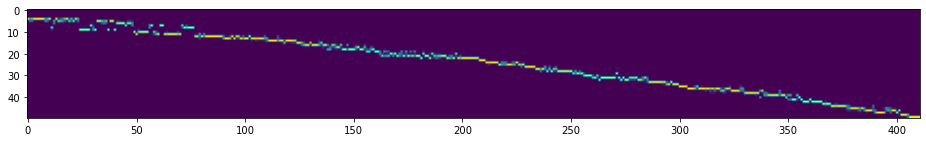

In [1773]:
plt.figure(figsize=(16, 9))
plt.imshow(model.model.gij.T[argsort, :])

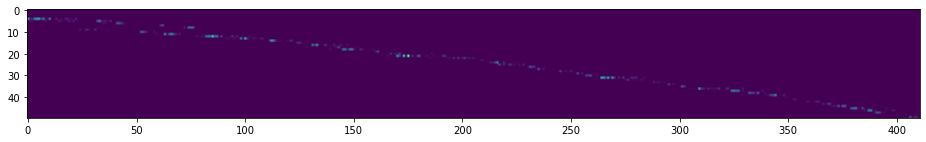

In [1774]:
plt.figure(figsize=(16, 9))
plt.imshow(model.model.X.T[argsort, :])

In [1775]:
# window_df.to_csv('tmp/window_df/window_df.csv')

Text(0, 0.5, 'заселенность, прочтения')

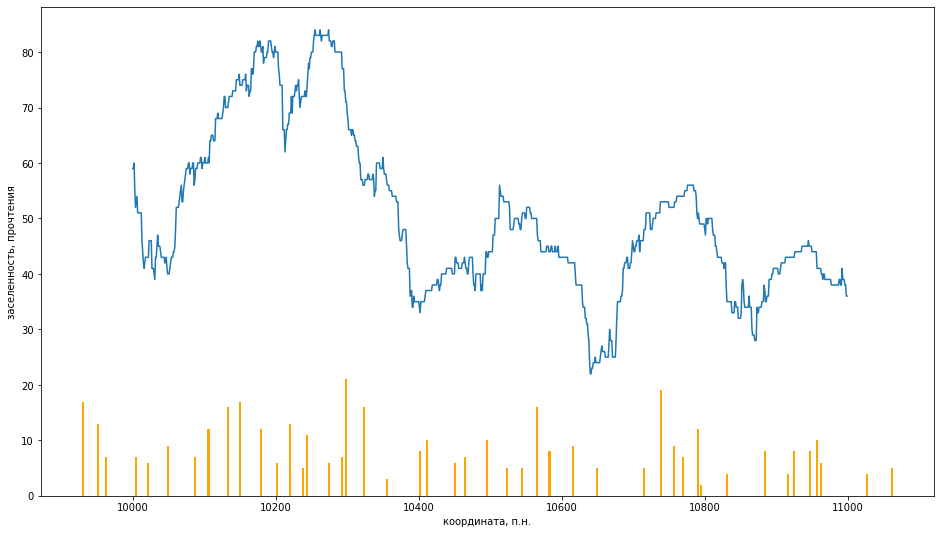

In [1776]:
fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=True, sharey=True)

ax.plot(np.arange(start, stop), coverage)
ax.bar(filtered_stat.dyad, filtered_stat["size"], 3, color="orange")
# sns.barplot(data=stat_df, x='dyad', y=stat_df['size'], ax=ax)
ax.set_xlabel("координата, п.н.")
ax.set_ylabel("заселенность, прочтения")

In [1777]:
# fig, ax = plt.subplots(1, 1, figsize=(16, 9), sharex=False, sharey=False)
# sns.barplot(data=window_df.groupby(['fold', 'dyad']).size().reset_index(), x='dyad', y=0, hue='fold')
# sns.lineplot(x=np.arange(start, stop), y=coverage)

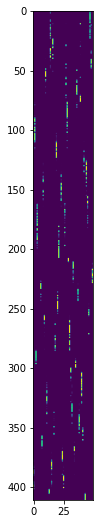

In [1778]:
gij = model.model.gij
plt.figure(figsize=(16, 9))
plt.imshow(gij)

In [1779]:
window_df.drop_duplicates(inplace=True)

NameError: name 'filtered_stat' is not defined

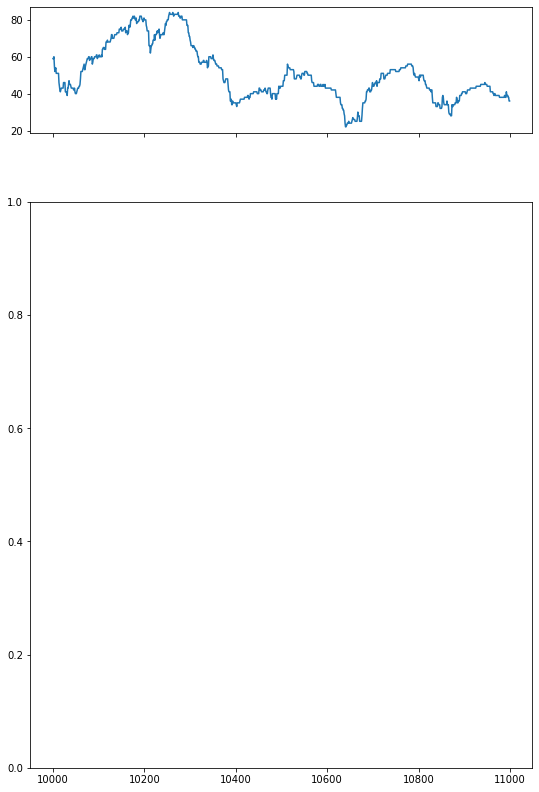

In [525]:
fig, ax = plt.subplots(
    2, 1, figsize=(9, 14), gridspec_kw=dict(height_ratios=[2, 9]), sharex=True
)

ax[0].plot(np.arange(start, stop), coverage)
ax[0].bar(filtered_stat.dyad, filtered_stat["size"], 3, color="orange")
ax[0].set_xlabel("координата, п.н.")
ax[0].set_ylabel("заселенность, прочтения")
# ax[0].grid()

grouped_var = filtered_df.sort_values("mid").dyad.to_numpy()
data = make_position_matrix(
    filtered_df.sort_values("mid")[["start", "stop"]].to_numpy(), grouped_var
)
data[data == 0] = np.nan
# data -= data[0,0]
ax[1].imshow(
    data, extent=(np.nanmin(stat_df.dyad), np.nanmax(stat_df.dyad), 0, data.shape[0])
)
# ax[1].bar(stat_df.dyad, np.ones_like(stat_df.dyad) * data.shape[0], 3, color='orange')
plt.tight_layout()
ax[1].grid()
fig.savefig("tmp/pictures/double_imshow.pdf")

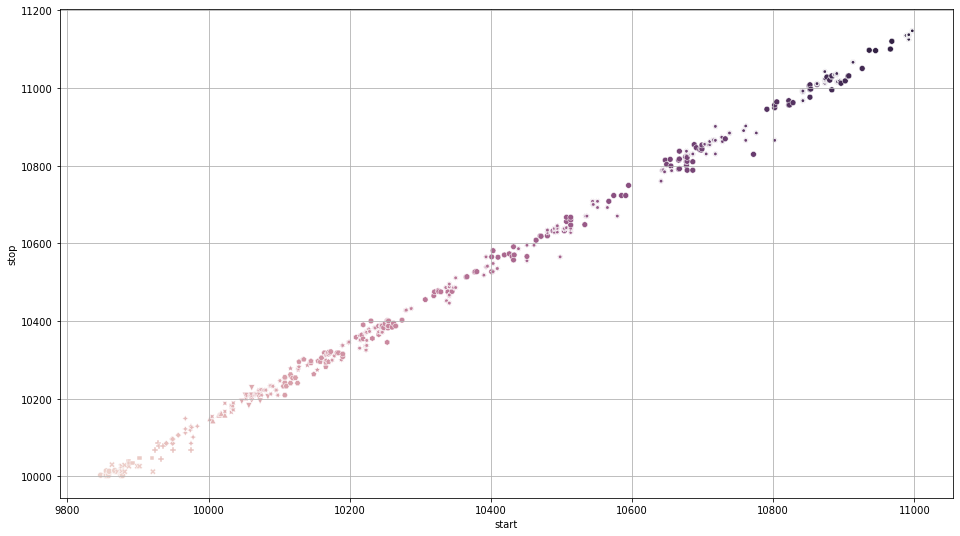

In [1783]:
# sns.kdeplot(data=df, x='start', y='stop')
plt.figure(figsize=(16, 9))
sns.scatterplot(
    data=filtered_df, x="start", y="stop", style="dyad", hue="dyad", legend=False
)
plt.grid()

In [1784]:
test_grid = {
    "n_nucs": np.arange(2, 20),
    "cluster_strategy": ["SEM", "DROPSEM"],
    "alpha": np.arange(1, 11) / 100,
    "max_iter": [1000, 2000],
}
gs = GridSearchCV(
    EMNucModel(1, "SEM", dpst.fit_res, 1000), test_grid, n_jobs=32, verbose=True
)

In [1785]:
gs_res = gs.fit(batch)

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py:63: UserWarning: Failed to kill subprocesses on this platform. Please installpsutil: https://github.com/giampaolo/psutil
Details:
Traceback (most recent call last):
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 59, in _kill_process_tree_without_psutil
    _posix_recursive_kill(process.pid)
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 111, in _posix_recursive_kill
    ["pgrep", "-P", str(pid)], stderr=None, text=True
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 356, in check_output
    **kwargs).stdout
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 423, in run
    with Popen(*popenargs, **kwargs) as process:
TypeError: __init__() got an unexpected keyword argument 'text'

 

KeyboardInterrupt: 

In [ ]:
resdf = pd.DataFrame(gs_res.cv_results_)

In [ ]:
resdf.sort_values("rank_test_score")

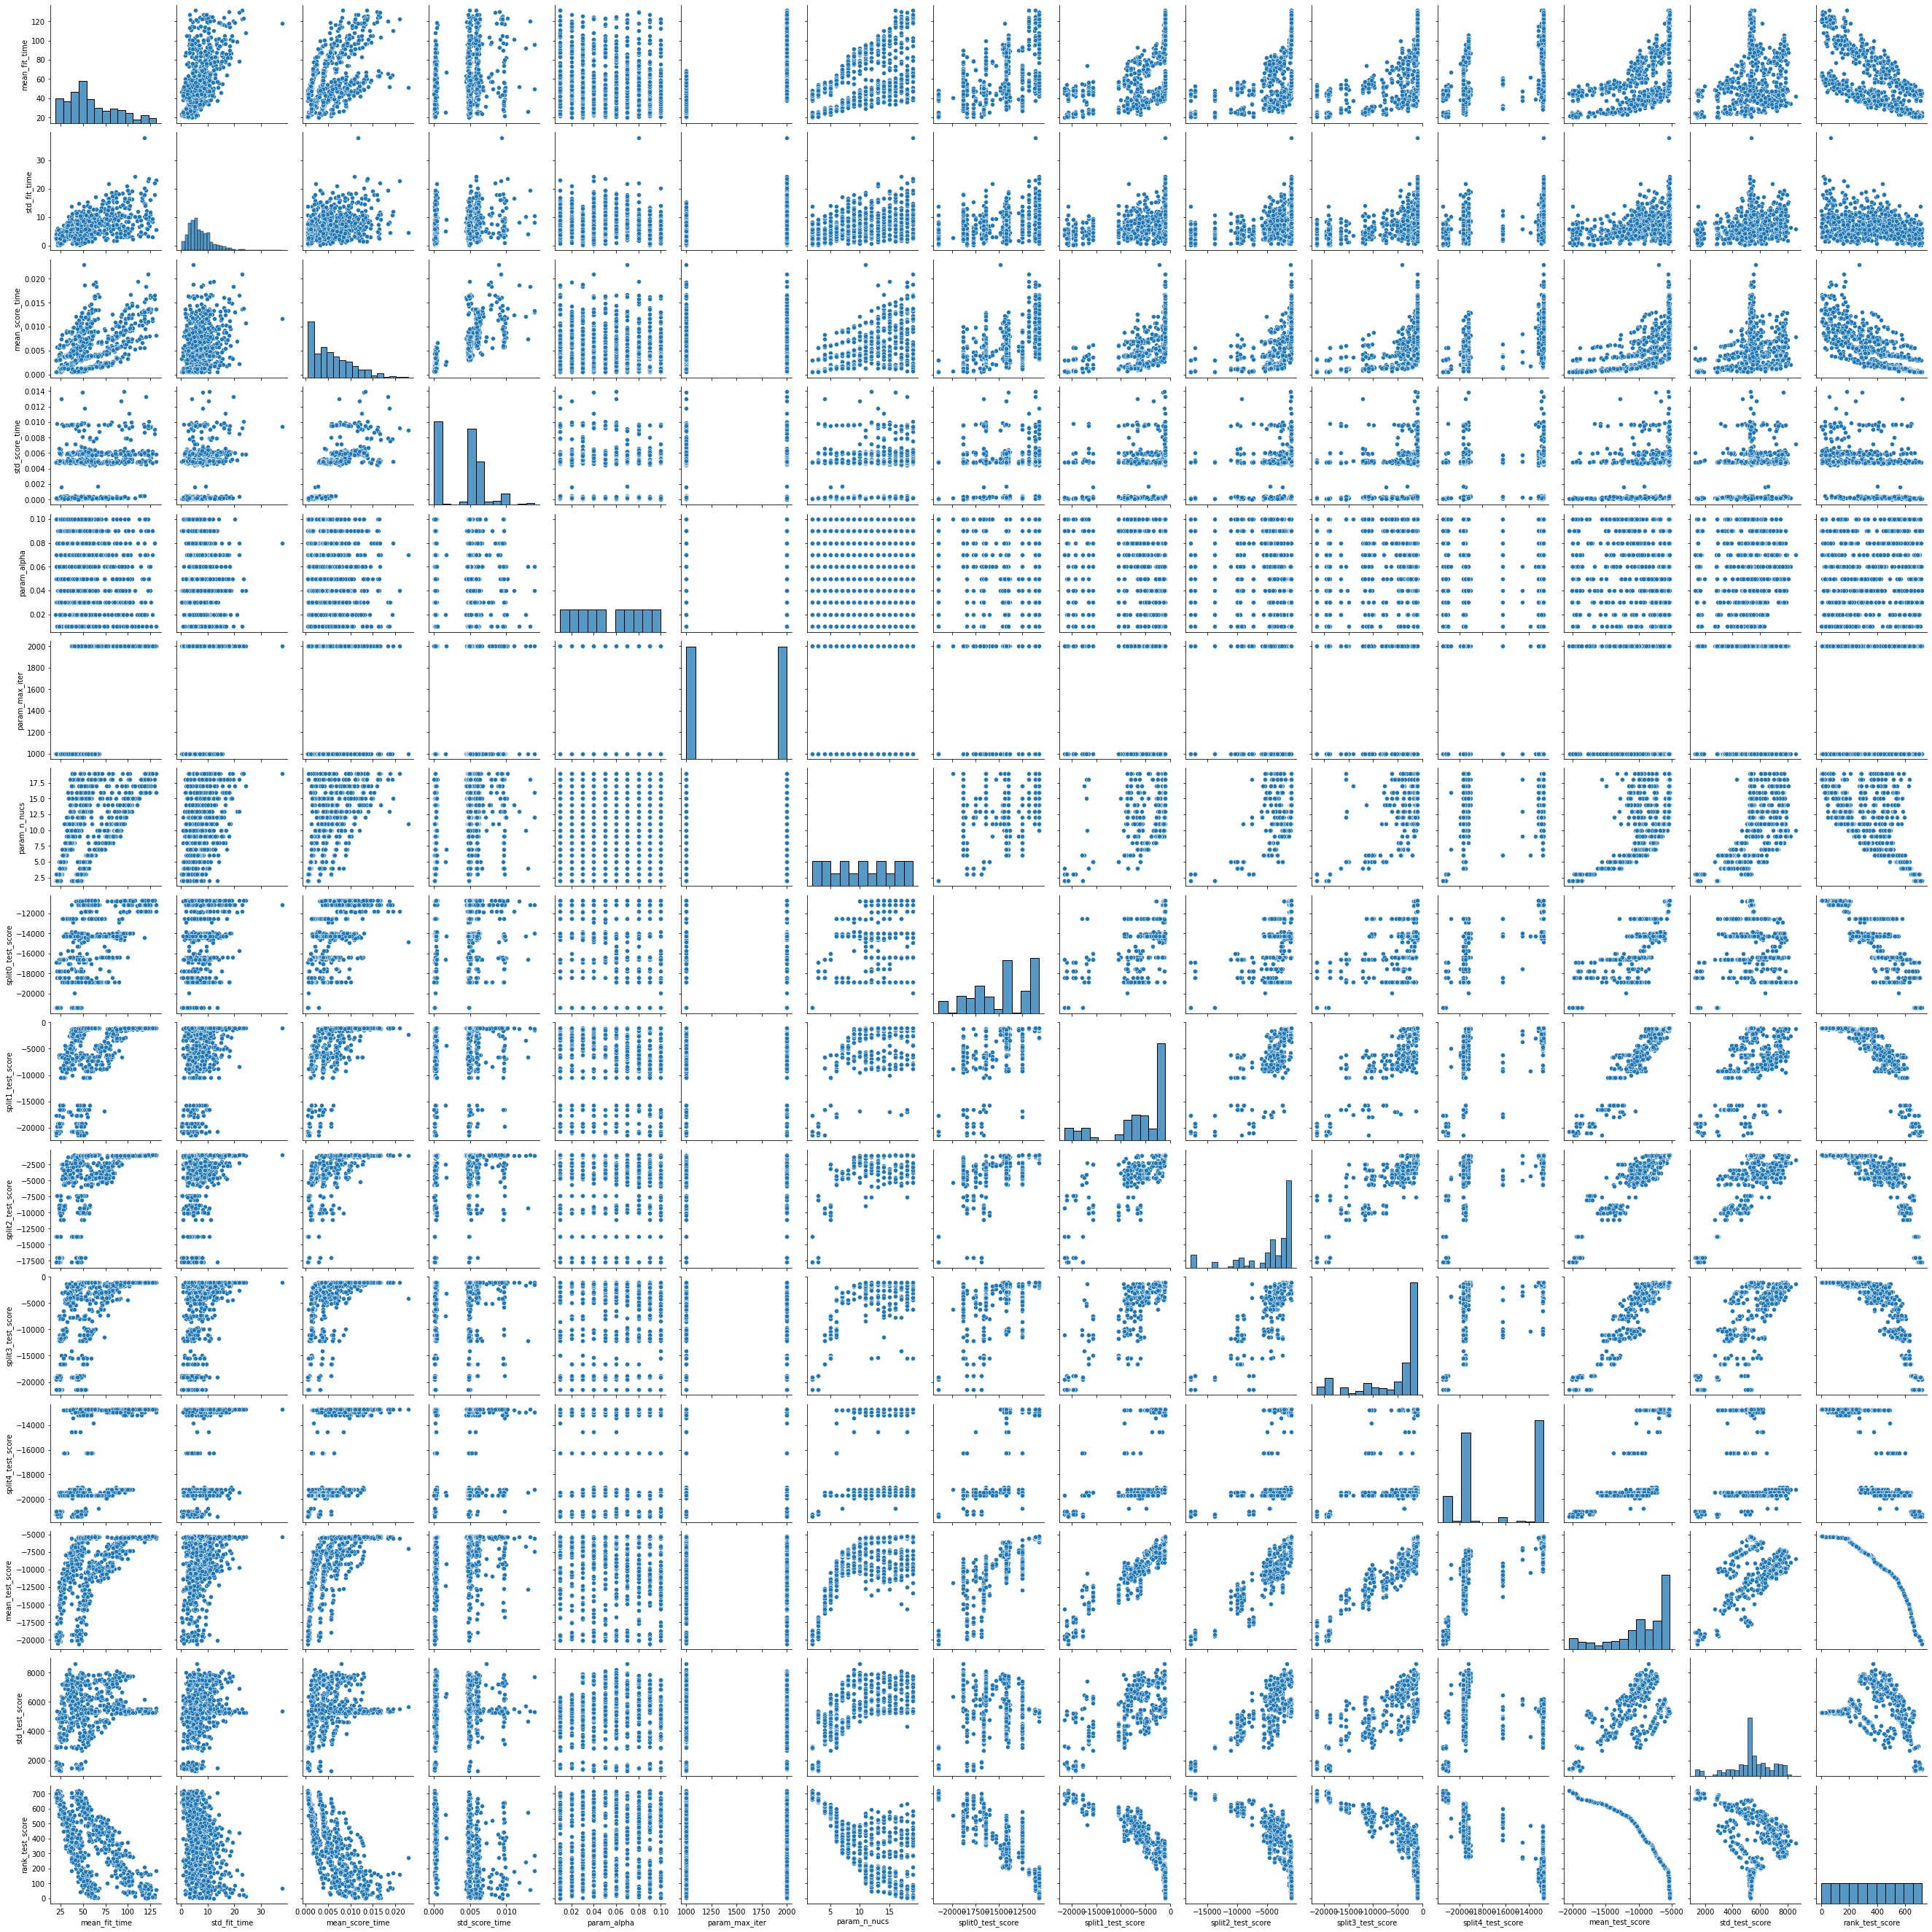

In [58]:
sns.pairplot(resdf)

<AxesSubplot:xlabel='mean_test_score', ylabel='Density'>

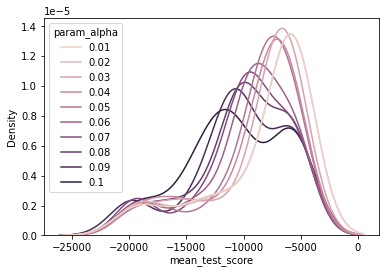

In [70]:
sns.kdeplot(
    data=resdf[["param_alpha", "mean_test_score"]],
    x="mean_test_score",
    hue="param_alpha",
)

<AxesSubplot:xlabel='mean_fit_time', ylabel='Density'>

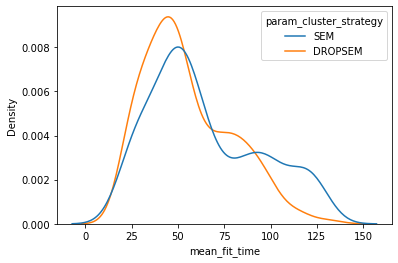

In [77]:
sns.kdeplot(data=resdf, x="mean_fit_time", hue="param_cluster_strategy")

<AxesSubplot:xlabel='mean_fit_time', ylabel='Density'>

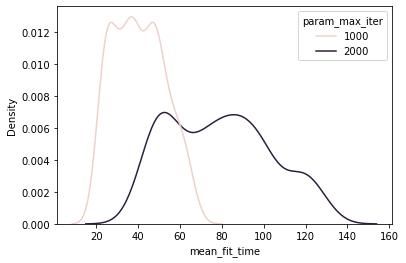

In [81]:
sns.kdeplot(data=resdf, x="mean_fit_time", hue="param_max_iter")

<AxesSubplot:xlabel='param_n_nucs', ylabel='mean_test_score'>

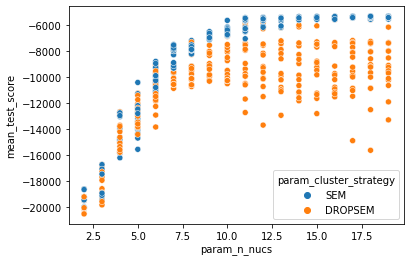

In [94]:
sns.scatterplot(
    data=resdf, x="param_n_nucs", y="mean_test_score", hue="param_cluster_strategy"
)

<AxesSubplot:xlabel='param_n_nucs', ylabel='mean_test_score'>

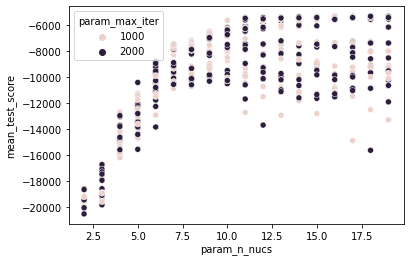

In [97]:
sns.scatterplot(data=resdf, x="param_n_nucs", y="mean_test_score", hue="param_max_iter")

In [118]:
resdf["rel_los"] = resdf.mean_test_score / resdf.param_n_nucs.T

In [122]:
resdf.sort_values("rel_los", ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,param_cluster_strategy,param_max_iter,param_n_nucs,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,rel_los
35,120.638700,12.159107,0.013335,0.009450,0.01,SEM,2000,19,"{'alpha': 0.01, 'cluster_strategy': 'SEM', 'ma...",-10725.933394,-1015.955872,-1005.146442,-1019.924364,-12715.532785,-5296.498571,5282.966345,1.0,-278.763
593,62.484502,10.682556,0.016268,0.005074,0.09,SEM,1000,19,"{'alpha': 0.09, 'cluster_strategy': 'SEM', 'ma...",-10727.236113,-1006.849911,-995.341300,-1041.499772,-12715.312696,-5297.247958,5282.759975,3.0,-278.803
17,66.225742,9.261487,0.016651,0.004983,0.01,SEM,1000,19,"{'alpha': 0.01, 'cluster_strategy': 'SEM', 'ma...",-10727.786680,-1018.940650,-987.020011,-1040.656492,-12714.689607,-5297.818688,5282.229436,4.0,-278.833
467,126.979315,3.091415,0.016202,0.004763,0.07,SEM,2000,19,"{'alpha': 0.07, 'cluster_strategy': 'SEM', 'ma...",-10725.917506,-1056.594031,-1001.147568,-1018.564547,-12715.373697,-5303.519470,5277.226580,7.0,-279.133
611,127.195608,9.490009,0.011636,0.005929,0.09,SEM,2000,19,"{'alpha': 0.09, 'cluster_strategy': 'SEM', 'ma...",-10727.221073,-1052.291422,-999.132677,-1039.799067,-12714.718709,-5306.632590,5274.890748,10.0,-279.296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,45.737444,4.551466,0.000583,0.000123,0.03,DROPSEM,2000,2,"{'alpha': 0.03, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.153597,-17710.911661,-19462.148189,-21197.466887,-20111.544340,1378.274697,717.0,-10055.8
252,25.573494,2.815095,0.000571,0.000090,0.04,DROPSEM,1000,2,"{'alpha': 0.04, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.144295,-17710.911661,-19462.148189,-21414.041365,-20154.857375,1414.643703,718.0,-10077.4
612,21.849374,0.968139,0.000524,0.000136,0.09,DROPSEM,1000,2,"{'alpha': 0.09, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.125777,-17710.911661,-21414.041365,-21197.466887,-20501.917411,1414.990909,719.0,-10251
630,45.183354,5.879218,0.000513,0.000104,0.09,DROPSEM,2000,2,"{'alpha': 0.09, 'cluster_strategy': 'DROPSEM',...",-21414.041365,-20773.125777,-17710.911661,-21414.041365,-21414.041365,-20545.232306,1438.735312,720.0,-10272.6


In [124]:
gs_res.best_estimator_

EMNucModel(alpha=0.01, cluster_strategy='SEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.338...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           max_iter=2000, n_nucs=19)

<AxesSubplot:xlabel='mean_fit_time', ylabel='param_max_iter'>

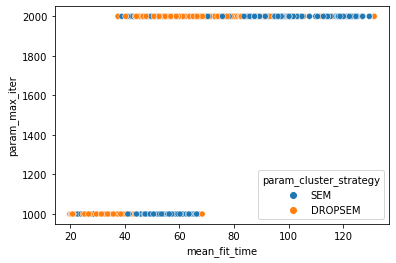

In [80]:
sns.scatterplot(
    data=resdf, x="mean_fit_time", y="param_max_iter", hue="param_cluster_strategy"
)

In [766]:
ntest_nucs = 5
read_amount = np.array([50, 30, 20, 10] * ntest_nucs)
assert ntest_nucs == len(read_amount)

internuc_dist = np.random.normal(200, 1, size=ntest_nucs - 1).astype(int)
start_pos = 150
nuc_pos = [start_pos]
test_nucs = []


for i in range(ntest_nucs - 1):
    new_pos = nuc_pos[i] + internuc_dist[i]
    nuc_pos.append(new_pos)
nuc_pos = np.array(nuc_pos)

for nofgroup in range(ntest_nucs):
    digestedNuc = dpst.digest_nucs(
        read_amount[nofgroup], nuc_pos[nofgroup], id_=nofgroup
    )
    test_nucs.extend(digestedNuc)

In [767]:
hue = list(map(lambda x: x.id, test_nucs))

In [768]:
test_batch = np.array(list(map(lambda x: [x.start, x.end], test_nucs)))

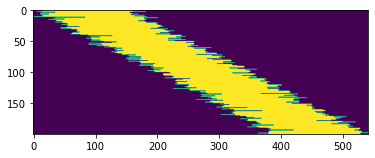

In [769]:
imshow = make_position_matrix(test_batch)
plt.imshow(imshow)

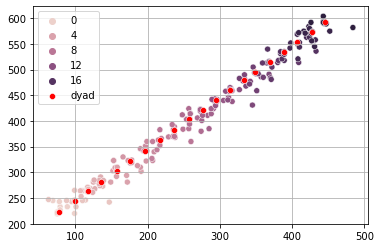

In [770]:
sns.scatterplot(x=test_batch[:, 0], y=test_batch[:, 1], hue=hue)
sns.scatterplot(x=nuc_pos - 73, y=nuc_pos + 73, color="red", label="dyad")
plt.grid()

In [771]:
test_model = EMNucModel(ntest_nucs, "SEM", dpst.fit_res, max_iter=1000)
test_model.fit(test_batch)

100%|██████████| 1000/1000 [00:43<00:00, 23.16it/s]


EMNucModel(cluster_strategy='SEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.33821416e-03,
       2...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           n_nucs=20)

In [772]:
test_model.model.gij

array([[0.        , 0.        , 0.78975059, ..., 0.        , 0.20966785,
        0.        ],
       [0.        , 0.        , 0.99051437, ..., 0.        , 0.00948563,
        0.        ],
       [0.        , 0.        , 0.16343397, ..., 0.        , 0.8163566 ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [773]:
w_test, pos_test = test_model.weights_, test_model.positions_

In [774]:
w_test

array([0.06 , 0.06 , 0.04 , 0.035, 0.075, 0.04 , 0.045, 0.06 , 0.025,
       0.065, 0.04 , 0.045, 0.075, 0.06 , 0.06 , 0.065, 0.04 , 0.   ,
       0.065, 0.045])

In [775]:
pos_test

array([270, 442, 149, 348, 500, 229, 191, 388, 290, 309, 406, 518, 460,
       367, 331, 209, 422,  63, 171, 249])

In [776]:
test_model.score(test_batch)

-1909.1348030337929

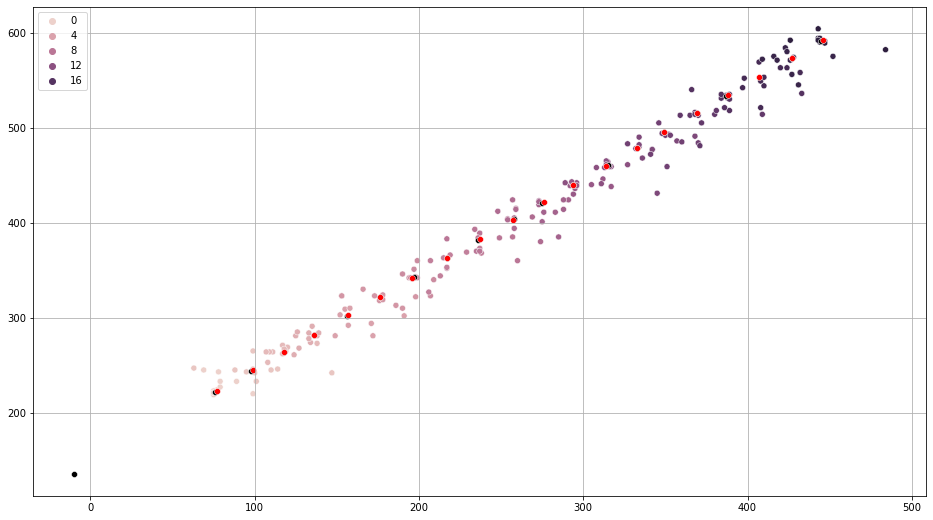

In [779]:
plt.figure(figsize=(16, 9))
sns.scatterplot(
    x=test_batch[:, 0], y=test_batch[:, 1], hue=list(map(lambda x: x.id, test_nucs))
)
sns.scatterplot(x=pos_test - 73, y=pos_test + 73, color="black")
sns.scatterplot(x=nuc_pos - 73, y=nuc_pos + 73, color="red")
plt.grid()

In [780]:
print(nuc_pos, pos_test)

[150 172 191 209 230 249 269 290 310 330 349 367 387 406 422 442 461 480
 500 519] [270 442 149 348 500 229 191 388 290 309 406 518 460 367 331 209 422  63
 171 249]


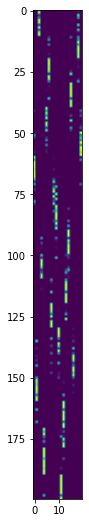

In [781]:
plt.figure(figsize=(16, 9))
plt.imshow(test_model.model.gij)

In [782]:
test_wd, test_stat = count_statistics(test_batch, test_model)

In [783]:
test_stat

,dyad,stat,size,p_vals
0,149,8.785507,7,0.268425
1,171,13.012824,14,0.525514
2,191,8.001687,9,0.533976
3,209,11.080402,12,0.522041
4,229,8.660626,8,0.371729
5,249,10.414836,9,0.317957
6,270,12.010589,13,0.526776
7,290,7.389771,5,0.193228
8,309,12.007726,13,0.527010
9,331,11.031508,11,0.440627


In [784]:
test_grid = {
    "n_nucs": np.arange(2, 10),
    "cluster_strategy": ["SEM", "DROPSEM"],
    "alpha": np.arange(1, 11) / 100,
}
gs = GridSearchCV(
    EMNucModel(1, "SEM", dpst.fit_res, 1000), test_grid, n_jobs=4, verbose=True
)

In [725]:
gs_res = gs.fit(test_batch)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py:63: UserWarning: Failed to kill subprocesses on this platform. Please installpsutil: https://github.com/giampaolo/psutil
Details:
Traceback (most recent call last):
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 59, in _kill_process_tree_without_psutil
    _posix_recursive_kill(process.pid)
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/site-packages/joblib/externals/loky/backend/utils.py", line 111, in _posix_recursive_kill
    ["pgrep", "-P", str(pid)], stderr=None, text=True
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 356, in check_output
    **kwargs).stdout
  File "/home/d_ryabov/.conda/envs/NucDPosIT/lib/python3.6/subprocess.py", line 423, in run
    with Popen(*popenargs, **kwargs) as process:
TypeError: __init__() got an unexpected keyword argument 'text'

 

ValueError: Invalid parameter alpha for estimator EMNucModel(cluster_strategy='SEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.33821416e-03,
       2...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           n_nucs=1). Check the list of available parameters with `estimator.g

In [698]:
gsdf_test = pd.DataFrame(gs_res.cv_results_)

In [699]:
gsdf_test

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_cluster_strategy,param_n_nucs,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.057413,0.147268,0.000953,0.000726,SEM,1,"{'cluster_strategy': 'SEM', 'n_nucs': 1}",-inf,-44.376548,-inf,-41.844225,-49.466187,-inf,NaN,17
1,2.096095,0.063568,0.000390,0.000033,SEM,2,"{'cluster_strategy': 'SEM', 'n_nucs': 2}",-29.587851,-27.718016,-37.750355,-33.975475,-35.754496,-32.957239,3.758660,12
2,2.276072,0.025925,0.001370,0.001143,SEM,3,"{'cluster_strategy': 'SEM', 'n_nucs': 3}",-29.058383,-27.718016,-37.716563,-33.975475,-39.495923,-33.592872,4.627586,15
3,2.434089,0.020872,0.000491,0.000050,SEM,4,"{'cluster_strategy': 'SEM', 'n_nucs': 4}",-30.198259,-27.718016,-37.716563,-33.975475,-34.775996,-32.876862,3.522072,10
4,2.623920,0.042968,0.000526,0.000041,SEM,5,"{'cluster_strategy': 'SEM', 'n_nucs': 5}",-30.918901,-26.710532,-37.716563,-33.975475,-39.495923,-33.763479,4.612340,16
5,2.798548,0.020571,0.000720,0.000070,SEM,6,"{'cluster_strategy': 'SEM', 'n_nucs': 6}",-29.650790,-26.710532,-37.716563,-33.703188,-34.775996,-32.511414,3.885245,3
6,2.978057,0.074913,0.000767,0.000074,SEM,7,"{'cluster_strategy': 'SEM', 'n_nucs': 7}",-29.580405,-27.319777,-37.716563,-33.975475,-35.754496,-32.869343,3.864142,9
7,3.125528,0.047958,0.000743,0.000063,SEM,8,"{'cluster_strategy': 'SEM', 'n_nucs': 8}",-29.650790,-28.434498,-37.716563,-33.703188,-34.775996,-32.856207,3.401536,8
8,3.320177,0.060580,0.000872,0.000076,SEM,9,"{'cluster_strategy': 'SEM', 'n_nucs': 9}",-29.650790,-27.718016,-37.800872,-33.975475,-35.754496,-32.979930,3.760365,13
9,1.875288,0.018414,0.000578,0.000593,DROPSEM,1,"{'cluster_strategy': 'DROPSEM', 'n_nucs': 1}",-inf,-44.376548,-inf,-41.844225,-49.466187,-inf,NaN,17


<AxesSubplot:xlabel='mean_test_score', ylabel='mean_test_score'>

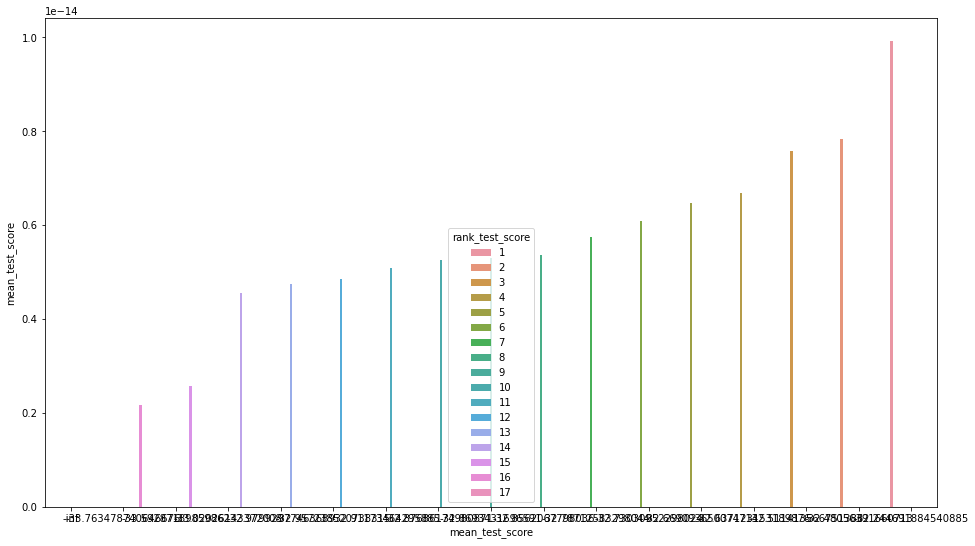

In [700]:
plt.figure(figsize=(16, 9))
sns.barplot(
    data=gsdf_test,
    x="mean_test_score",
    y=np.exp(gsdf_test.mean_test_score),
    hue="rank_test_score",
)

In [712]:
best_test_wd, best_test_stat = count_statistics(test_batch, gs_res.best_estimator_)

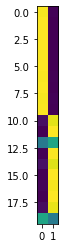

In [713]:
plt.imshow(gs_res.best_estimator_.model.gij)

In [714]:
best_model = gs_res.best_estimator_

In [715]:
best_test_wd, best_test_stat = count_statistics(test_batch, best_model)

In [716]:
best_test_stat

,dyad,stat,size,p_vals
0,150,12.116631,11,0.354941
1,171,9.794589,9,0.367369


In [717]:
test_stat

,dyad,stat,size,p_vals
0,150,12.116631,11,0.354941
1,171,9.794589,9,0.367369


In [718]:
best_test_wd.head()

,start,stop,mid,dyad,nuc_prob,prob,stat
0,72,225,148.5,150,0.55,0.992065,0.066820
1,77,226,151.5,150,0.55,0.996112,0.066820
2,77,193,135.0,150,0.55,1.000000,6.681965
3,67,224,145.5,150,0.55,0.998454,0.601377
4,77,227,152.0,150,0.55,0.995611,0.118790


In [723]:
best_model

EMNucModel(cluster_strategy='DROPSEM',
           fit_res=array([1.43621777e-03, 8.61620150e-04, 4.43562938e-04, 2.40685385e-04,
       2.84158806e-04, 5.37725234e-04, 9.05284292e-04, 1.27619107e-03,
       1.52457358e-03, 1.56757311e-03, 1.44062835e-03, 1.16552947e-03,
       8.61546581e-04, 6.70886089e-04, 7.15798839e-04, 1.08152670e-03,
       1.73342920e-03, 2.51507892e-03, 3.13087598e-03, 3.33821416e-...
       9.38574762e-04, 8.22423123e-04, 7.33178542e-04, 6.17824261e-04,
       4.77234599e-04, 2.70483609e-04, 3.19629624e-05, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 1.41687741e-05, 1.61108112e-04,
       2.07264553e-04, 1.30680998e-04, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 4.25661451e-05, 1.95427263e-04,
       9.65275698e-05]),
           n_nucs=3)

In [709]:
best_model.positions_

array([150, 171])

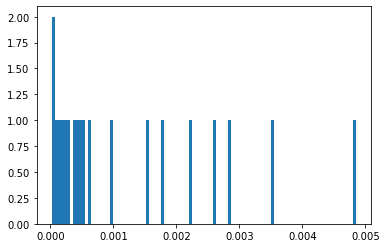

In [710]:
_ = plt.hist(test_model.model.X.sum(axis=1), bins=100)

In [711]:
best_model.model.weights

array([0.55, 0.45])